In [1]:
# plot the results for the gene sets in the over and under expressed genes

In [2]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [3]:
# all TCGA

TCGA_UP_ALL = pd.read_table('/Users/kazachkova/Documents/alexandrov_lab/mutographs/CRC_clonal_analysis/V3_Data/examine_SBS288D/Reviewers_Comments/Reviewers_comments_V2/GSEA_results_TCGA_SWEDISH/TCGA_UP_ALL.tsv',on_bad_lines='skip',
             skiprows=[0,1,2,3,4,5,6,7,8],index_col=0).loc[:,['k/K','FDR q-value']].dropna()

TCGA_UP_50 = pd.read_table('/Users/kazachkova/Documents/alexandrov_lab/mutographs/CRC_clonal_analysis/V3_Data/examine_SBS288D/Reviewers_Comments/Reviewers_comments_V2/GSEA_results_TCGA_SWEDISH/TCGA_UP_50.tsv',on_bad_lines='skip',
             skiprows=[0,1,2,3,4,5,6,7,8],index_col=0).loc[:,['k/K','FDR q-value']].dropna()


# TCGA up 25 and 10 don't have anything
# TCGA_UP_25 = pd.read_table('GSEA_results_TCGA_SWEDISH/TCGA_UP_25.tsv',on_bad_lines='skip',
#              skiprows=[0,1,2,3,4,5,6,7,8],index_col=0).loc[:,['k/K','FDR q-value']].dropna()

TCGA_UP_25  = pd.DataFrame(columns = ['k/K','FDR q-value'])
TCGA_UP_10  = pd.DataFrame(columns = ['k/K','FDR q-value'])

SWEDISH_UP_ALL = pd.read_table('/Users/kazachkova/Documents/alexandrov_lab/mutographs/CRC_clonal_analysis/V3_Data/examine_SBS288D/Reviewers_Comments/Reviewers_comments_V2/GSEA_results_TCGA_SWEDISH/SWEDISH_ALL_UP.tsv',on_bad_lines='skip',
             skiprows=[0,1,2,3,4,5,6,7,8],index_col=0).loc[:,['k/K','FDR q-value']].dropna()

SWEDISH_UP_50 = pd.read_table('/Users/kazachkova/Documents/alexandrov_lab/mutographs/CRC_clonal_analysis/V3_Data/examine_SBS288D/Reviewers_Comments/Reviewers_comments_V2/GSEA_results_TCGA_SWEDISH/SWEDISH_UP_50.tsv',on_bad_lines='skip',
             skiprows=[0,1,2,3,4,5,6,7,8],index_col=0).loc[:,['k/K','FDR q-value']].dropna()

SWEDISH_UP_25 = pd.read_table('/Users/kazachkova/Documents/alexandrov_lab/mutographs/CRC_clonal_analysis/V3_Data/examine_SBS288D/Reviewers_Comments/Reviewers_comments_V2/GSEA_results_TCGA_SWEDISH/SWEDISH_UP_25.tsv',on_bad_lines='skip',
             skiprows=[0,1,2,3,4,5,6,7,8],index_col=0).loc[:,['k/K','FDR q-value']].dropna()

SWEDISH_UP_10 = pd.read_table('/Users/kazachkova/Documents/alexandrov_lab/mutographs/CRC_clonal_analysis/V3_Data/examine_SBS288D/Reviewers_Comments/Reviewers_comments_V2/GSEA_results_TCGA_SWEDISH/SWEDISH_UP_10.tsv',on_bad_lines='skip',
             skiprows=[0,1,2,3,4,5,6,7,8],index_col=0).loc[:,['k/K','FDR q-value']].dropna()

TCGA_UP_ALL['cohort'] = 'TCGA\n(ALL SBS_D+)'
TCGA_UP_50['cohort'] = 'TCGA\n(Top 50% SBS_D+)'
# TCGA_UP_25['cohort'] = 'TCGA (Top 25% SBS_D+)'

SWEDISH_UP_ALL['cohort'] = 'Swedish\n(ALL SBS_D+)'
SWEDISH_UP_50['cohort'] = 'Swedish\n(Top 50% SBS_D+)'
SWEDISH_UP_25['cohort'] = 'Swedish\n(Top 25% SBS_D+)'
SWEDISH_UP_10['cohort'] = 'Swedish\n(Top 10% SBS_D+)'


In [5]:
from collections import Counter

all_together = pd.concat([SWEDISH_UP_ALL, SWEDISH_UP_50,SWEDISH_UP_25,SWEDISH_UP_10,
          TCGA_UP_ALL,TCGA_UP_50])


num_each = pd.Series(Counter(all_together.index))
all_together['num_each'] = num_each


any_TCGA = set(TCGA_UP_ALL.index | TCGA_UP_50.index)
any_SWEDISH = set(SWEDISH_UP_ALL.index | SWEDISH_UP_50.index |
                SWEDISH_UP_25.index |  SWEDISH_UP_10.index)
in_both = (any_TCGA & any_SWEDISH)



all_together = all_together.reset_index()

##### Manually add cohorts with no sig gene sets #####
manually_add_TCGA_25 = pd.Series(['GOBP_EPITHELIUM_DEVELOPMENT',float('NaN'),float('NaN'),'TCGA\n(Top 25% SBS_D+)',0],
          index = all_together.columns)
all_together = all_together.append(manually_add_TCGA_25,ignore_index=True)
      

/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_86965/2315863007.py:11: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead.
  any_TCGA = set(TCGA_UP_ALL.index | TCGA_UP_50.index)
/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_86965/2315863007.py:12: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead.
  any_SWEDISH = set(SWEDISH_UP_ALL.index | SWEDISH_UP_50.index |
/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_86965/2315863007.py:23: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_together = all_together.append(manually_add_TCGA_25,ignore_index=True)


/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_86965/2909601691.py:13: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead.
  any_TCGA = set(TCGA_UP_ALL.index | TCGA_UP_50.index)
/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_86965/2909601691.py:14: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead.
  any_SWEDISH = set(SWEDISH_UP_ALL.index | SWEDISH_UP_50.index |


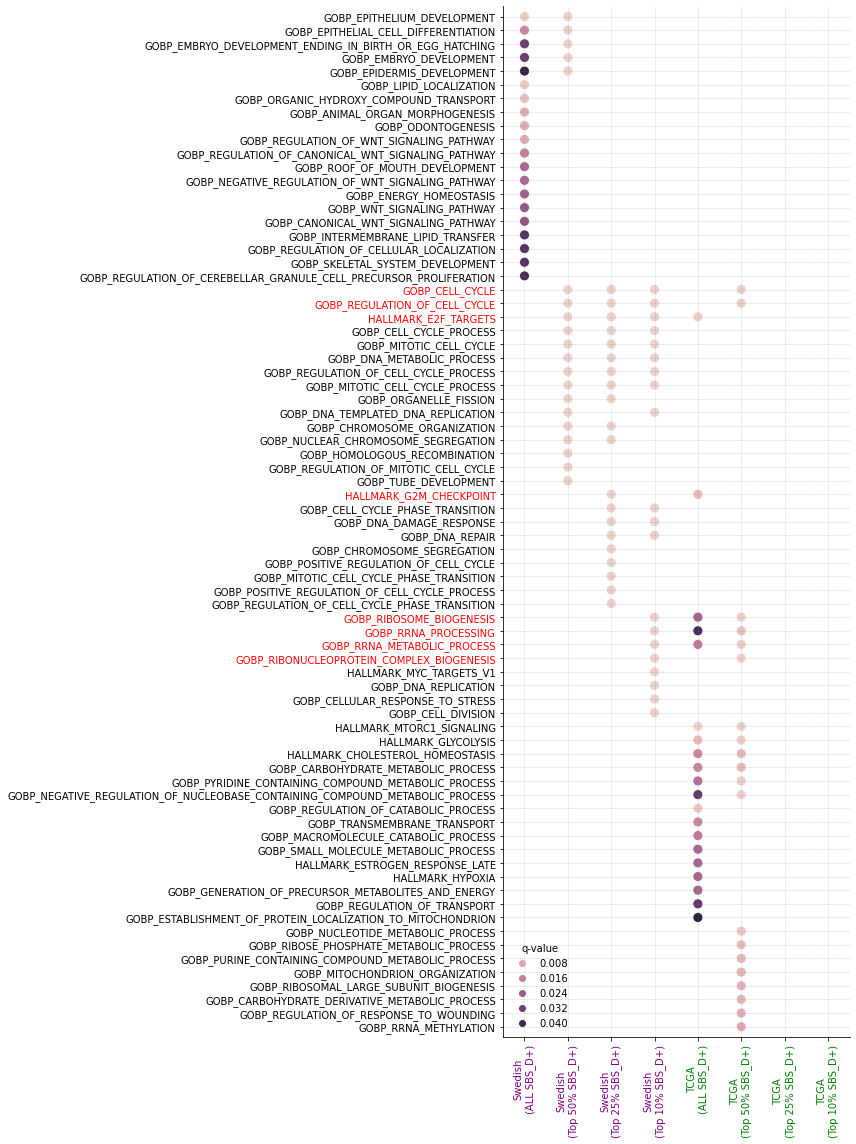

In [6]:
# plot for all over expressed

from collections import Counter

all_together = pd.concat([SWEDISH_UP_ALL, SWEDISH_UP_50,SWEDISH_UP_25,SWEDISH_UP_10,
          TCGA_UP_ALL,TCGA_UP_50])


num_each = pd.Series(Counter(all_together.index))
all_together['num_each'] = num_each


any_TCGA = set(TCGA_UP_ALL.index | TCGA_UP_50.index)
any_SWEDISH = set(SWEDISH_UP_ALL.index | SWEDISH_UP_50.index |
                SWEDISH_UP_25.index |  SWEDISH_UP_10.index)
in_both = (any_TCGA & any_SWEDISH)



all_together = all_together.reset_index()

##### Manually add missing cohorts #####
# manually_add_TCGA_25 = pd.Series(['GOBP_EPITHELIUM_DEVELOPMENT',0,float('NaN'),'TCGA\n(Top 25% SBS_D+)',1],
#           index = all_together.columns)
# all_together = all_together.append(manually_add_TCGA_25,ignore_index=True)


# manually_add_TCGA_10 = pd.Series(['GOBP_EPITHELIUM_DEVELOPMENT',0,float('NaN'),'TCGA\n(Top 10% SBS_D+)',1],
#           index = all_together.columns)
# all_together = all_together.append(manually_add_TCGA_10,ignore_index=True)


all_together['cohort'] = pd.Categorical(all_together['cohort'], ['Swedish\n(ALL SBS_D+)',
                                                       'Swedish\n(Top 50% SBS_D+)',
                                                      'Swedish\n(Top 25% SBS_D+)',
                                                      'Swedish\n(Top 10% SBS_D+)',
                                                      'TCGA\n(ALL SBS_D+)',
                                                      'TCGA\n(Top 50% SBS_D+)',
                                                      'TCGA\n(Top 25% SBS_D+)',
                                                                'TCGA\n(Top 10% SBS_D+)'])


all_together = all_together.sort_values(['cohort','num_each'],ascending=[True,False])

fig,ax = plt.subplots(figsize=(12,16))
sns.scatterplot(data=all_together,
               x='cohort',y='Gene Set Name',hue='FDR q-value',
               s=100,)




cats = all_together['cohort'].cat.categories
ax.set_xticks(range(len(cats)))
ax.set_xticklabels(cats)
ax.set_xlim(-0.5, len(cats) - 0.5)

for label in ax.get_yticklabels():
    if label.get_text() in (in_both):  # Check for specific tick value
        label.set_color('red')
        
        
for label in ax.get_xticklabels():
    if 'TCGA' in label.get_text():  # Check for specific tick value
        label.set_color('Green')
#         label.set_fontweight('bold')
    if 'Swedish' in label.get_text():  # Check for specific tick value
        label.set_color('Purple') 
#         label.set_fontweight('bold')





plt.ylabel("Y-axis Label", fontweight='bold')
plt.ylabel('')
plt.xlabel('')

plt.margins(y=.01, tight=True) 
plt.legend(loc='lower left',title='q-value',frameon=False)
plt.xticks(rotation=90)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(10)
    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='both', color='gray', linestyle='--', linewidth=0.5, alpha=0.4)

plt.tight_layout()

# plt.savefig('plots_for_responses/ALL_UP.png',dpi=300)

In [7]:
# now the down 

# all TCGA

# TCGA_DOWN_ALL = pd.read_table('GSEA_results_TCGA_SWEDISH/TCGA_DOWN_ALL.tsv',on_bad_lines='skip',
#              skiprows=[0,1,2,3,4,5,6,7,8],index_col=0).loc[:,['k/K','FDR q-value']].dropna()

TCGA_DOWN_50 = pd.read_table('/Users/kazachkova/Documents/alexandrov_lab/mutographs/CRC_clonal_analysis/V3_Data/examine_SBS288D/Reviewers_Comments/Reviewers_comments_V2/GSEA_results_TCGA_SWEDISH/TCGA_DOWN_50.tsv',on_bad_lines='skip',
             skiprows=[0,1,2,3,4,5,6,7,8],index_col=0).loc[:,['k/K','FDR q-value']].dropna()


# TCGA DOWN 25 and 10 don't have anything
# TCGA_DOWN_25 = pd.read_table('GSEA_results_TCGA_SWEDISH/TCGA_DOWN_25.tsv',on_bad_lines='skip',
#              skiprows=[0,1,2,3,4,5,6,7,8],index_col=0).loc[:,['k/K','FDR q-value']].dropna()

# TCGA_DOWN_25  = pd.DataFrame(columns = ['k/K','FDR q-value'])
# TCGA_DOWN_10  = pd.DataFrame(columns = ['k/K','FDR q-value'])

SWEDISH_DOWN_ALL = pd.read_table('/Users/kazachkova/Documents/alexandrov_lab/mutographs/CRC_clonal_analysis/V3_Data/examine_SBS288D/Reviewers_Comments/Reviewers_comments_V2/GSEA_results_TCGA_SWEDISH/SWEDISH_ALL_DOWN.tsv',on_bad_lines='skip',
             skiprows=[0,1,2,3,4,5,6,7,8],index_col=0).loc[:,['k/K','FDR q-value']].dropna()

SWEDISH_DOWN_50 = pd.read_table('/Users/kazachkova/Documents/alexandrov_lab/mutographs/CRC_clonal_analysis/V3_Data/examine_SBS288D/Reviewers_Comments/Reviewers_comments_V2/GSEA_results_TCGA_SWEDISH/SWEDISH_DOWN_50.tsv',on_bad_lines='skip',
             skiprows=[0,1,2,3,4,5,6,7,8],index_col=0).loc[:,['k/K','FDR q-value']].dropna()

SWEDISH_DOWN_25 = pd.read_table('/Users/kazachkova/Documents/alexandrov_lab/mutographs/CRC_clonal_analysis/V3_Data/examine_SBS288D/Reviewers_Comments/Reviewers_comments_V2/GSEA_results_TCGA_SWEDISH/SWEDISH_DOWN_25.tsv',on_bad_lines='skip',
             skiprows=[0,1,2,3,4,5,6,7,8],index_col=0).loc[:,['k/K','FDR q-value']].dropna()

SWEDISH_DOWN_10 = pd.read_table('/Users/kazachkova/Documents/alexandrov_lab/mutographs/CRC_clonal_analysis/V3_Data/examine_SBS288D/Reviewers_Comments/Reviewers_comments_V2/GSEA_results_TCGA_SWEDISH/SWEDISH_DOWN_10.tsv',on_bad_lines='skip',
             skiprows=[0,1,2,3,4,5,6,7,8],index_col=0).loc[:,['k/K','FDR q-value']].dropna()

# TCGA_DOWN_ALL['cohort'] = 'TCGA (ALL SBS_D+)'
TCGA_DOWN_50['cohort'] = 'TCGA\n(Top 50% SBS_D+)'
# TCGA_DOWN_25['cohort'] = 'TCGA (Top 25% SBS_D+)'

SWEDISH_DOWN_ALL['cohort'] = 'Swedish\n(ALL SBS_D+)'
SWEDISH_DOWN_50['cohort'] = 'Swedish\n(Top 50% SBS_D+)'
SWEDISH_DOWN_25['cohort'] = 'Swedish\n(Top 25% SBS_D+)'
SWEDISH_DOWN_10['cohort'] = 'Swedish\n(Top 10% SBS_D+)'


/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_86965/3187315583.py:12: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead.
  any_SWEDISH = set(SWEDISH_DOWN_ALL.index | SWEDISH_DOWN_50.index |


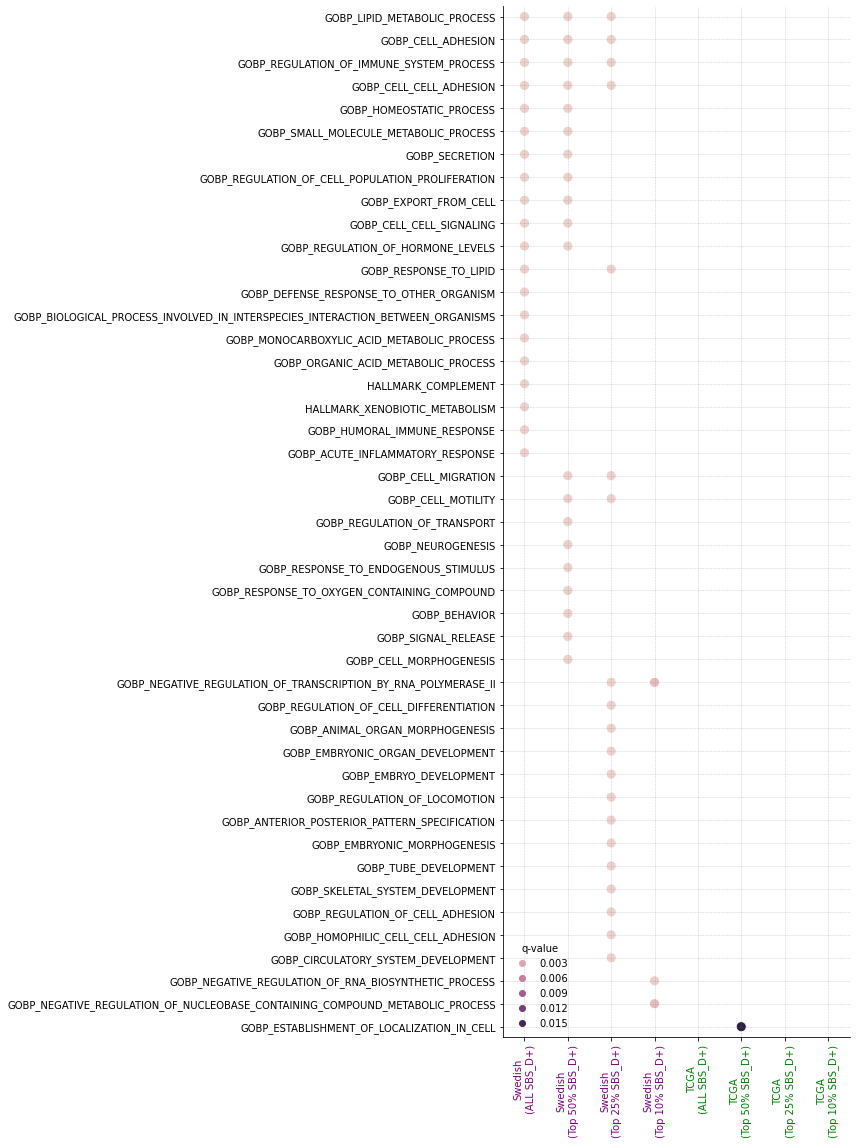

In [8]:
from collections import Counter

all_together = pd.concat([SWEDISH_DOWN_ALL, SWEDISH_DOWN_50,SWEDISH_DOWN_25,SWEDISH_DOWN_10,
          TCGA_DOWN_50])


num_each = pd.Series(Counter(all_together.index))
all_together['num_each'] = num_each


any_TCGA = set(TCGA_DOWN_50.index)
any_SWEDISH = set(SWEDISH_DOWN_ALL.index | SWEDISH_DOWN_50.index |
                SWEDISH_DOWN_25.index |  SWEDISH_DOWN_10.index)
in_both = (any_TCGA & any_SWEDISH)



all_together = all_together.reset_index()

##### Manually add missing cohorts #####
# manually_add_TCGA_25 = pd.Series(['GOBP_EPITHELIUM_DEVELOPMENT',0,float('NaN'),'TCGA\n(Top 25% SBS_D+)',1],
#           index = all_together.columns)
# all_together = all_together.append(manually_add_TCGA_25,ignore_index=True)


# manually_add_TCGA_10 = pd.Series(['GOBP_EPITHELIUM_DEVELOPMENT',0,float('NaN'),'TCGA\n(Top 10% SBS_D+)',1],
#           index = all_together.columns)
# all_together = all_together.append(manually_add_TCGA_10,ignore_index=True)


all_together['cohort'] = pd.Categorical(all_together['cohort'], ['Swedish\n(ALL SBS_D+)',
                                                       'Swedish\n(Top 50% SBS_D+)',
                                                      'Swedish\n(Top 25% SBS_D+)',
                                                      'Swedish\n(Top 10% SBS_D+)',
                                                      'TCGA\n(ALL SBS_D+)',
                                                      'TCGA\n(Top 50% SBS_D+)',
                                                      'TCGA\n(Top 25% SBS_D+)',
                                                                'TCGA\n(Top 10% SBS_D+)'])


all_together = all_together.sort_values(['cohort','num_each'],ascending=[True,False])

fig,ax = plt.subplots(figsize=(12,16))
sns.scatterplot(data=all_together,
               x='cohort',y='Gene Set Name',hue='FDR q-value',
               s=100,)




cats = all_together['cohort'].cat.categories
ax.set_xticks(range(len(cats)))
ax.set_xticklabels(cats)
ax.set_xlim(-0.5, len(cats) - 0.5)

for label in ax.get_yticklabels():
    if label.get_text() in (in_both):  # Check for specific tick value
        label.set_color('red')
        
        
for label in ax.get_xticklabels():
    if 'TCGA' in label.get_text():  # Check for specific tick value
        label.set_color('Green')
#         label.set_fontweight('bold')
    if 'Swedish' in label.get_text():  # Check for specific tick value
        label.set_color('Purple') 
#         label.set_fontweight('bold')





plt.ylabel("Y-axis Label", fontweight='bold')
plt.ylabel('')
plt.xlabel('')

plt.margins(y=.01, tight=True) 
plt.legend(loc='lower left',title='q-value',frameon=False)
plt.xticks(rotation=90)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(10)
    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='both', color='gray', linestyle='--', linewidth=0.5, alpha=0.4)

plt.tight_layout()

# plt.savefig('plots_for_responses/ALL_DOWN.png',dpi=300)